In [1]:
# Packages
import itertools
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
from scipy.stats import poisson
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, zero_one_loss
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


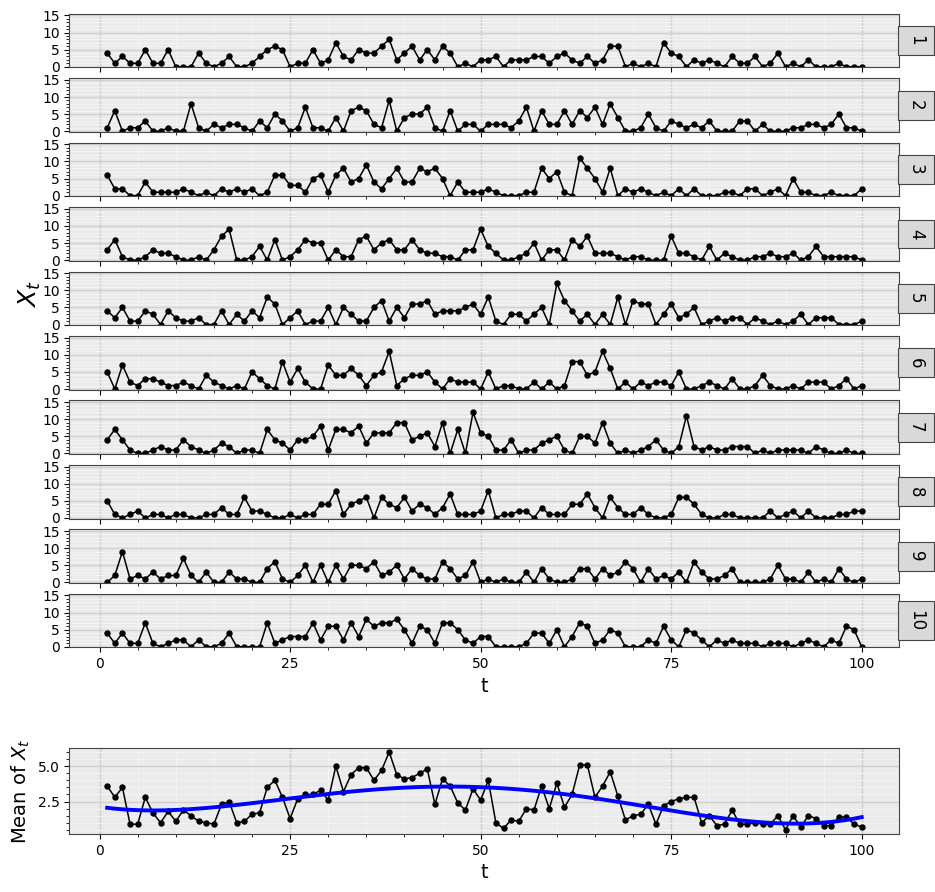

In [ ]:
# Part 1
def build_Gamma(beta, gamma):
    """Build the 3x3 transition matrix Γ for the Markov chain C_t ∈ {0,1,2}.

    Rows are current state i, columns are next state j:
        Γ[i, j] = P(C_{t+1}=j | C_t=i)
    """
    if not (0 < beta < 1):
        raise ValueError(f"Beta must be between 0 and 1: Your input: {beta}")
    if not (0 < gamma < 1):
        raise ValueError(f"Gamma must be between 0 and 1. Your input: {gamma}")

    Gamma = np.array(
        [
            [1 - gamma, 0, gamma],
            [0, 1 - gamma, gamma],
            [beta / 2, beta / 2, 1 - beta],
        ]
    )
    return Gamma


def simulate_C(T, Gamma) -> list[int]:
    """Simulate the hidden Markov chain C_1,...,C_T ∈ {0,1,2} using transition matrix Γ.

    We assume P(C_1 = 2) = 1. For each step t, sample C_{t+1} from the categorical
    distribution given by the row Γ[C_t, :].
    """
    C_t = [2]  # Definition P(C_1 = 2) = 1

    for _ in range(T - 1):
        u = np.random.rand()  # Generate a X ∼ Unif(0, 1)
        row = Gamma[C_t[-1]]  # Get the latest index
        p0, p1, _ = row  # Get the value of that index

        if u < p0:
            C_t.append(0)
        elif u < p0 + p1:
            C_t.append(1)
        else:
            C_t.append(2)
    return C_t


def simulate_Z(C, alpha, T, n):
    """Simulate attention variables Z_{t,i} ∈ {0,1} for t=1,...,T and i=1,...,n.

    Conditional on the hidden state C_t, the variables Z_{t,i} are
    independent Bernoulli random variables with

        P(Z_{t,i}=1 | C_t=0) = 1 - alpha
        P(Z_{t,i}=1 | C_t=1) = alpha
        P(Z_{t,i}=1 | C_t=2) = 0.5

    Returns:
        Z: array of shape (T, n)
    """
    if not (0.5 < alpha < 1):
        raise ValueError(f"Alpha must be a value between 0.5 and 1: Your input {alpha}")

    C = np.asarray(C)
    if C.shape[0] != T:
        raise ValueError(f"C must have the length of T: Your input C has: {C.shape[0]}")

    p = np.empty(T, dtype=float)  # shape(T,)
    p[C == 0] = 1 - alpha
    p[C == 1] = alpha
    p[C == 2] = 0.5

    Z = np.random.binomial(n=1, p=p[:, None], size=(T, n)).astype(int)
    return Z


def simulate_X(Z, lambda0, lambda1):
    """Simulate observed spike counts X_{t,i} given attention variables Z_{t,i}.

    Conditional on Z_{t,i}, the observations are independent Poisson variables:

        X_{t,i} | Z_{t,i}=0 ~ Poisson(lambda0)
        X_{t,i} | Z_{t,i}=1 ~ Poisson(lambda1)

    Returns:
        X: array of shape (T, n)
    """
    if lambda0 < 0 or lambda1 < 0:
        raise ValueError("Both lambda0 and lambda1 most be bigger than 0")
    rates = np.where(Z == 0, lambda0, lambda1)
    X = np.random.poisson(lam=rates)
    return X


def simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1):
    # Simulate data
    Gamma = build_Gamma(beta, gamma)
    C = simulate_C(T, Gamma)  # List length T
    Z = simulate_Z(C, alpha, T, n)  # Shape (T, n)
    X = simulate_X(Z, lambda0, lambda1)  # Shape (T, n)
    return np.asarray(C, dtype=int), X


# Part 2
def illustrate_hidden_Markov_model(X, T, n, degree=4):
    """Illustrate the hidden Markov model generated"""
    t = np.arange(1, T + 1, dtype=float)
    x_mean = X.mean(axis=1)
    y_fit = np.polyval(np.polyfit(t, x_mean, deg=degree), t)

    ymax = max(10, 5 * math.ceil((X.max() + 1) / 5))

    fig = plt.figure(figsize=(10, 0.72 * n + 2.8), facecolor="#ffffff")
    outer = fig.add_gridspec(2, 1, height_ratios=[n, 1.35], hspace=0.28)
    upper = outer[0].subgridspec(n, 1, hspace=0.20)

    axes = [fig.add_subplot(upper[0, 0])]
    for i in range(1, n):
        axes.append(fig.add_subplot(upper[i, 0], sharex=axes[0]))

    ax_mean = fig.add_subplot(outer[1, 0], sharex=axes[0])

    def style_axis(ax):
        ax.set_facecolor("#ebebeb")
        ax.set_axisbelow(True)
        ax.grid(True, which="major", color="#d0d0d0", linewidth=1.0)
        ax.grid(True, which="minor", color="#f3f3f3", linewidth=0.8)
        ax.minorticks_on()
        ax.xaxis.set_major_locator(MultipleLocator(25))
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        for spine in ax.spines.values():
            spine.set_color("#444444")
            spine.set_linewidth(0.8)

    for i, ax in enumerate(axes, start=1):
        ax.plot(t, X[:, i - 1], "o-", color="black", linewidth=1.1, markersize=3.6)
        ax.set_ylim(-0.2, ymax + 0.5)
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        style_axis(ax)

        if i < n:
            ax.tick_params(labelbottom=False)
        else:
            ax.set_xlabel("t", fontsize=14)

        ax.text(
            1.02,
            0.5,
            f"{i}",
            transform=ax.transAxes,
            rotation=270,
            va="center",
            ha="center",
            fontsize=12,
            bbox=dict(
                boxstyle="square,pad=0.55",
                facecolor="#d9d9d9",
                edgecolor="#444444",
                linewidth=0.8,
            ),
            clip_on=False,
        )

    ax_mean.plot(t, x_mean, "o-", color="black", linewidth=1.1, markersize=3.6)
    ax_mean.plot(t, y_fit, color="blue", linewidth=2.8)
    style_axis(ax_mean)
    ax_mean.set_ylabel(r"Mean of $X_t$", fontsize=14)
    ax_mean.set_xlabel("t", fontsize=14)

    fig.text(0.06, 0.62, r"$X_t$", rotation=90, va="center", ha="center", fontsize=18)
    fig.subplots_adjust(left=0.10, right=0.93, top=0.90, bottom=0.08)

    plt.show()


if __name__ == "__main__":
    #Parameters
    T = 100  # Number of time steps per simulated sequence (length of C_1..C_T and X_1..X_T)
    n = 10  # Number of neurons / spike-count channels (X_t is a length-n vector; also feature dimension if you use only one time step)

    beta = 0.2  # Transition parameter from state 2: P(2→0)=beta/2, P(2→1)=beta/2, P(2→2)=1-beta (controls how often you leave state 2)
    gamma = 0.1  # Transition parameter from states 0 and 1: P(0→2)=gamma, P(0→0)=1-gamma and P(1→2)=gamma, P(1→1)=1-gamma (controls how often you jump to state 2)

    alpha = 0.9  # Attention bias: P(Z=1|C=1)=alpha (high), P(Z=1|C=0)=1-alpha (low), P(Z=1|C=2)=0.5 (neutral)

    lambda0 = 1  # Poisson rate for spikes when Z=0 (low-rate firing regime)
    lambda1 = 5  # Poisson rate for spikes when Z=1 (high-rate firing regime)

    num_sims = 20000  # Number of independent simulated sequences used to form the

    t_index = 5  # Which time step you extract as the training example/label (0-based; 5 means the 6th time point)

    C, X = simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1)
    illustrate_hidden_Markov_model(X, T, n)


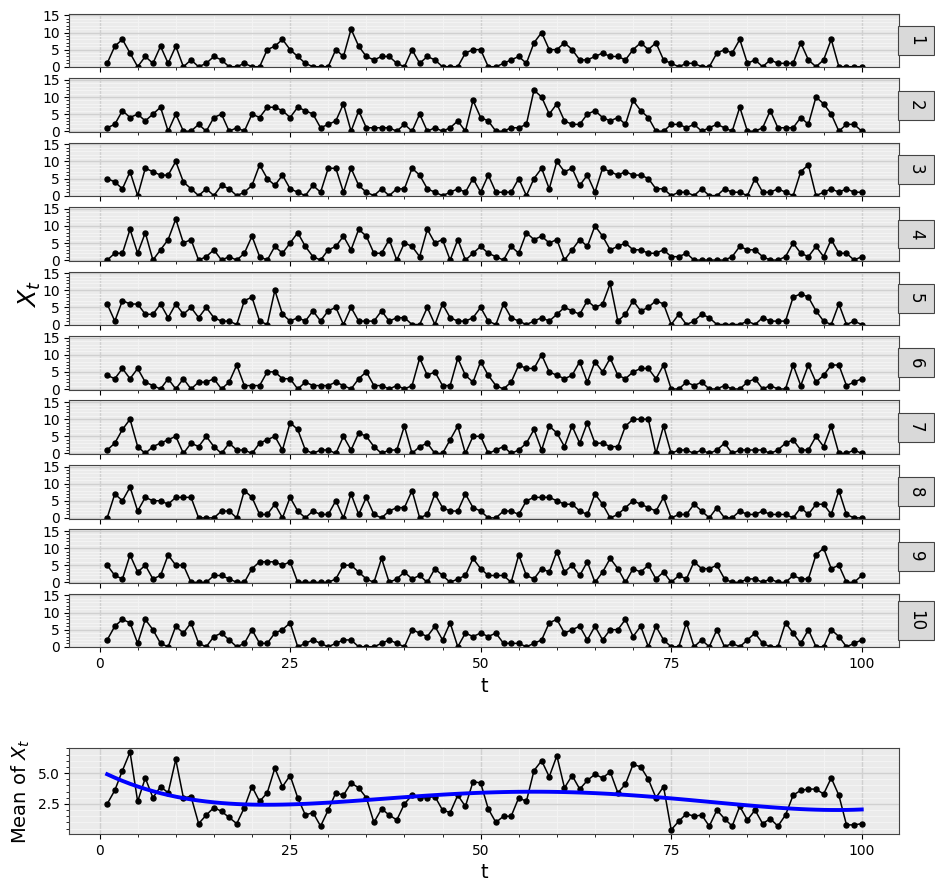

In [3]:
# Part 3
def make_lr_dataset(num_sims, t_index, n, T, beta, gamma, alpha, lambda0, lambda1):
    if not (0 <= t_index < T):
        raise ValueError("t_index must be between 0 and T-1")

    X_feature = np.empty(shape=(num_sims, n), dtype=int)
    y = np.empty(shape=(num_sims,), dtype=int)

    for k in range(num_sims):
        C, X = simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1)
        X_feature[k, :] = X[t_index, :]
        y[k] = C[t_index]

    return X_feature, y


def split_lr_dataset(X, y, test_size=0.2):
    return train_test_split(X, y, test_size=test_size, random_state=42)


def logistic_regression(X_train, y_train, X_test, y_test):
    clf = LogisticRegression(random_state=42, max_iter=10000, C=1, solver="lbfgs")
    clf.fit(X_train, y_train)

    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    print(f"Train 0-1 loss: {zero_one_loss(y_train, yhat_train):.4f}")
    print(f"Test  0-1 loss: {zero_one_loss(y_test, yhat_test):.4f}")
    print("Confusion matrix (test):\n", confusion_matrix(y_test, yhat_test))
    print(classification_report(y_test, yhat_test, digits=3))

    return clf


if __name__ == "__main__":
    T = 100  # Number of time steps per simulated sequence (length of C_1..C_T and X_1..X_T)
    n = 10  # Number of neurons / spike-count channels (X_t is a length-n vector; also feature dimension if you use only one time step)

    beta = 0.2  # Transition parameter from state 2: P(2→0)=beta/2, P(2→1)=beta/2, P(2→2)=1-beta (controls how often you leave state 2)
    gamma = 0.1  # Transition parameter from states 0 and 1: P(0→2)=gamma, P(0→0)=1-gamma and P(1→2)=gamma, P(1→1)=1-gamma (controls how often you jump to state 2)

    alpha = 0.9  # Attention bias: P(Z=1|C=1)=alpha (high), P(Z=1|C=0)=1-alpha (low), P(Z=1|C=2)=0.5 (neutral)

    lambda0 = 1  # Poisson rate for spikes when Z=0 (low-rate firing regime)
    lambda1 = 5  # Poisson rate for spikes when Z=1 (high-rate firing regime)

    num_sims = 20000  # Number of independent simulated sequences used to form the

    t_index = 5  # Which time step you extract as the training example/label (0-based; 5 means the 6th time point)
    C, X = simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1)
    illustrate_hidden_Markov_model(X, T, n)

    # X, y = make_lr_dataset(num_sims, t_index, n, T, beta, gamma, alpha, lambda0, lambda1)
    # X_train, X_test, y_train, y_test = split_lr_dataset(X, y)
    # clf = logistic_regression(X_train, y_train, X_test, y_test)
    # C_true, X_full = simulate_one_sequence(T=100, n=10, beta=0.2, gamma=0.1, alpha=0.9, lambda0=1, lambda1=5)
    # plot_of_mean(X_full, degree=4)

# Inference


In [ ]:
#local evidence is all messages from the observed data.
def get_local_evidence(X_t, n, alpha, lam0, lam1):
    # P(Z=1 | C) for C in [0, 1, 2]
    p_z1_given_c = np.array([1 - alpha, alpha, 0.5])

    # Probabilities of the counts under both Poisson regimes
    prob_z0 = poisson.pmf(X_t, lam0)
    prob_z1 = poisson.pmf(X_t, lam1)

    evidence_c = np.ones(3)

    for c in range(3):
        # For each neuron, marginalize out Z
        term_z1 = p_z1_given_c[c] * prob_z1
        term_z0 = (1 - p_z1_given_c[c]) * prob_z0
        evidence_c[c] = np.prod(term_z1 + term_z0)

    return evidence_c


def inference(X_full, T, n, beta, gamma, alpha, lam0, lam1):
    check_calibration = False  # Set to True to perform a calibration check of the inferred posteriors

    # 1. Setup Transition Matrix Gamma
    Gamma = np.array([[1 - gamma, 0, gamma], [0, 1 - gamma, gamma], [beta / 2, beta / 2, 1 - beta]])

    # 2. Local Evidence for all T
    local_ev = np.array([get_local_evidence(X_full[t], n, alpha, lam0, lam1) for t in range(T)])
    #print ("Local evidence shape:", local_ev.shape)  # Should be (T, 3)
    # 3. Forward Pass
    forward = np.zeros((T, 3))
    forward[0] = np.array([0, 0, 1]) * local_ev[0]  # Initial state
    forward[0] /= forward[0].sum()

    for t in range(1, T):
        forward[t] = local_ev[t] * (forward[t - 1] @ Gamma)
        forward[t] /= forward[t].sum()  # Normalize to avoid underflow

    # 4. Backward Pass
    backward = np.zeros((T, 3))
    backward[-1] = np.ones(3)

    for t in range(T - 2, -1, -1):
        backward[t] = Gamma @ (local_ev[t + 1] * backward[t + 1])
        backward[t] /= backward[t].sum()

    # 5. Compute Beliefs for C_t (P(C_t | X))
    posterior_c = forward * backward
    posterior_c /= posterior_c.sum(axis=1, keepdims=True)
    
    # 6. Compute Beliefs for Z_{t,i} (P(Z_{t,i} = 1 | X))
    # We use Bayes: P(Z=1|X,C) = P(X|Z=1)P(Z=1|C) / P(X|C)
    posterior_z = np.zeros((T, n))
    p_z1_given_c = np.array([1 - alpha, alpha, 0.5])

    """
    for t in range(T):
        # Probability of observed spikes given Z=1 and Z=0
        prob_x_z1 = poisson.pmf(X_full[t], lam1)
        prob_x_z0 = poisson.pmf(X_full[t], lam0)

        for c in range(3):
            # Local probability P(Z_{t,i}=1 | X_{t,i}, C_t=c)
            num = prob_x_z1 * p_z1_given_c[c]
            den = (prob_x_z1 * p_z1_given_c[c]) + (prob_x_z0 * (1 - p_z1_given_c[c]))
            p_z_given_x_c = num / den

            # Marginalize over the posterior of C_t
            posterior_z[t] += p_z_given_x_c * posterior_c[t, c]
    """

    posterior_z = np.zeros((T, n))
    p_z1_given_c = np.array([1 - alpha, alpha, 0.5])
    p_z0_given_c = 1 - p_z1_given_c

    for t in range(T):
        # 1. Probabilities of observed spikes for ALL neurons at time t
        prob_z1 = poisson.pmf(X_full[t], lam1) # Shape (n,)
        prob_z0 = poisson.pmf(X_full[t], lam0) # Shape (n,)
        if t == 0:
            past_msg = np.array([0, 0, 1]) 
        else:
            # Message from the past (forward message from t-1 to t) without local evidence
            past_msg = forward[t-1] @ Gamma
        
        msg_spine = past_msg * backward[t]
        
        
        for i in range(n):
            m_c_to_zi = (prob_z1[i] * p_z1_given_c) + (prob_z0[i] * p_z0_given_c)
            
            # The message sent "down" from C to Zi 
            msg_down = msg_spine * (local_ev[t] / (m_c_to_zi))

            #normalise
            msg_down /= msg_down.sum()
            
            # Sum over the 3 states of C for the two cases of Z
            term1 = np.sum(prob_z1[i] * p_z1_given_c * msg_down)
            term0 = np.sum(prob_z0[i] * p_z0_given_c * msg_down)
            
            #note no normalisation needed as we are only interested in the ratio of term1 and term0
            posterior_z[t, i] = term1 / (term1 + term0)


    if check_calibration:
        # Check that the inferred posterior of C_t is consistent with the joint distribution
        t_check = T - 2  # Second to last time step
        joint_clique = np.outer(forward[t_check], 1.0) * Gamma * (local_ev[t_check + 1] * backward[t_check + 1])
        joint_clique /= joint_clique.sum()

        # Check marginal consistency
        marginal_ct = joint_clique.sum(axis=1)  # Sum over Ct+1
        # This should be identical to posterior_c[t_check]
        assert np.allclose(marginal_ct, posterior_c[t_check])
        print("Calibration check passed: Marginals are consistent with the joint distribution.")

    #print("Inference completed. Posterior shapes - C:", posterior_c.shape, "Z:", posterior_z.shape)

    return posterior_c, posterior_z


# Testing that mean of bias is 0


In [20]:
def simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1):
    # Simulate data
    Gamma = build_Gamma(beta, gamma)
    C = simulate_C(T, Gamma)  # List length T
    Z = simulate_Z(C, alpha, T, n)  # Shape (T, n)
    X = simulate_X(Z, lambda0, lambda1)  # Shape (T, n)
    return np.asarray(C, dtype=int), Z, X


def test_inference_calibration(num_trials=1000):
    # Parameters as specified in the project description
    T = 100
    n = 10
    beta = 0.2
    gamma = 0.1
    alpha = 0.9
    lam0 = 1
    lam1 = 5

    # Storage for residuals (Indicator - Probability)
    # We track all 3 states for C and the attention for Z
    diffs_c = []
    diffs_z = []

    print(f"Running {num_trials} trials for calibration testing...")

    for _ in range(num_trials):
        # 1. Generate ground truth usingart I simulation
        # C_true: (T,), Z_true: (T, n), X_sim: (T, n)
        C_true, Z_true, X_sim = simulate_one_sequence(T, n, beta, gamma, alpha, lam0, lam1)

        # 2. Run the Part II inference algorithm
        # post_c: (T, 3), post_z: (T, n)
        post_c, post_z = inference(X_sim, T, n, beta, gamma, alpha, lam0, lam1)

        # 3. Compute C residuals: 1(Ct = c) - P(Ct = c | X)
        # We create an indicator matrix (T, 3) where the true state is 1 and others are 0
        c_indicator = np.zeros((T, 3))
        for t in range(T):
            c_indicator[t, C_true[t]] = 1

        diffs_c.append(c_indicator - post_c)

        # 4. Compute Z residuals: 1(Zti = 1) - P(Zti = 1 | X)
        # Z_true is already 0s and 1s, acting as its own indicator
        diffs_z.append(Z_true - post_z)

    # Convert lists to arrays for global averaging
    diffs_c = np.array(diffs_c)  # Shape: (num_trials, T, 3)
    diffs_z = np.array(diffs_z)  # Shape: (num_trials, T, n)

    # Calculate mean bias across all trials, time steps, and neurons
    bias_c = np.mean(diffs_c, axis=(0, 1))
    bias_z = np.mean(diffs_z)

    print("\n--- Calibration Results (Expected: ~0.0000) ---")
    print(f"Bias for C=0 (Serial 0): {bias_c[0]:.5f}")
    print(f"Bias for C=1 (Serial 1): {bias_c[1]:.5f}")
    print(f"Bias for C=2 (Parallel): {bias_c[2]:.5f}")
    print(f"Bias for Z (Attention):  {bias_z:.5f}")

    # Sanity check: Total bias should be extremely low
    if np.all(np.abs(bias_c) < 0.05) and np.abs(bias_z) < 0.005:
        print("\nResult: SUCCESS. The inference algorithm is unbiased.")
    else:
        print("\nResult: WARNING. Significant bias detected. Check Gamma or Local Evidence.")


# run the test:
test_inference_calibration(num_trials=1000)

Running 1000 trials for calibration testing...


UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

# Brute force testing


In [18]:
def brute_force_inference(X_full, T, n, beta, gamma, alpha, lam0, lam1):
    # 1. Setup Transition Matrix and Prior
    Gamma = np.array([[1 - gamma, 0, gamma], [0, 1 - gamma, gamma], [beta / 2, beta / 2, 1 - beta]])
    prior = np.array([0, 0, 1])  # P(C1=2) = 1

    # 2. Pre-calculate Local Evidence P(X_t | C_t) for all t
    # Using the function we wrote earlier
    local_ev = np.array([get_local_evidence(X_full[t], n, alpha, lam0, lam1) for t in range(T)])

    # 3. Generate all 3^T possible state sequences
    # For T=3, this is 27 sequences; for T=10, it's 59,049
    all_paths = list(itertools.product([0, 1, 2], repeat=T))

    path_probabilities = []

    for path in all_paths:
        # Initial probability: P(c1) * P(X1 | c1)
        prob = prior[path[0]] * local_ev[0, path[0]]

        # Multiply by transitions and evidence for the rest of the path
        for t in range(1, T):
            prob *= Gamma[path[t - 1], path[t]] * local_ev[t, path[t]]

        path_probabilities.append(prob)

    path_probabilities = np.array(path_probabilities)
    total_evidence = np.sum(path_probabilities)  # This is P(X)

    # 4. Compute Marginal P(Ct = c | X)
    # Sum the probabilities of all paths where Ct equals c
    brute_posterior_c = np.zeros((T, 3))
    for t in range(T):
        for c in range(3):
            # Sum prob of paths where the state at time t is c
            mask = [path[t] == c for path in all_paths]
            brute_posterior_c[t, c] = np.sum(path_probabilities[mask]) / total_evidence

    return brute_posterior_c


T_small, n_small = 10, 2
C_sim, Z_sim, X_sim = simulate_one_sequence(T_small, n_small, 0.2, 0.1, 0.9, 1, 5)

# Get results from both methods
post_fb, _ = inference(X_sim, T_small, n_small, 0.2, 0.1, 0.9, 1, 5)
post_bf = brute_force_inference(X_sim, T_small, n_small, 0.2, 0.1, 0.9, 1, 5)

# Compare
is_correct = np.allclose(post_fb, post_bf)
print(f"Brute Force Match: {is_correct}")
print("Difference Max:", np.max(np.abs(post_fb - post_bf)))
if not is_correct:
    print("Difference Max:", np.max(np.abs(post_fb - post_bf)))

Brute Force Match: True
Difference Max: 4.440892098500626e-16


In [7]:
# Part 3
# Load data
def load_data(filepath):
    """Load data_file and split columns accordingly"""
    df = pd.read_csv(filepath, sep=",")
    t = df["t"].to_numpy()  # time
    X = df.filter(regex=r"^X\d+$").to_numpy()
    T, n = X.shape

    # Test of t and X
    assert np.array_equal(t, np.arange(1, T + 1))  # t = 1, ..., T
    assert (X >= 0).all()  # Check all X >= 0
    return df, t, X, T, n


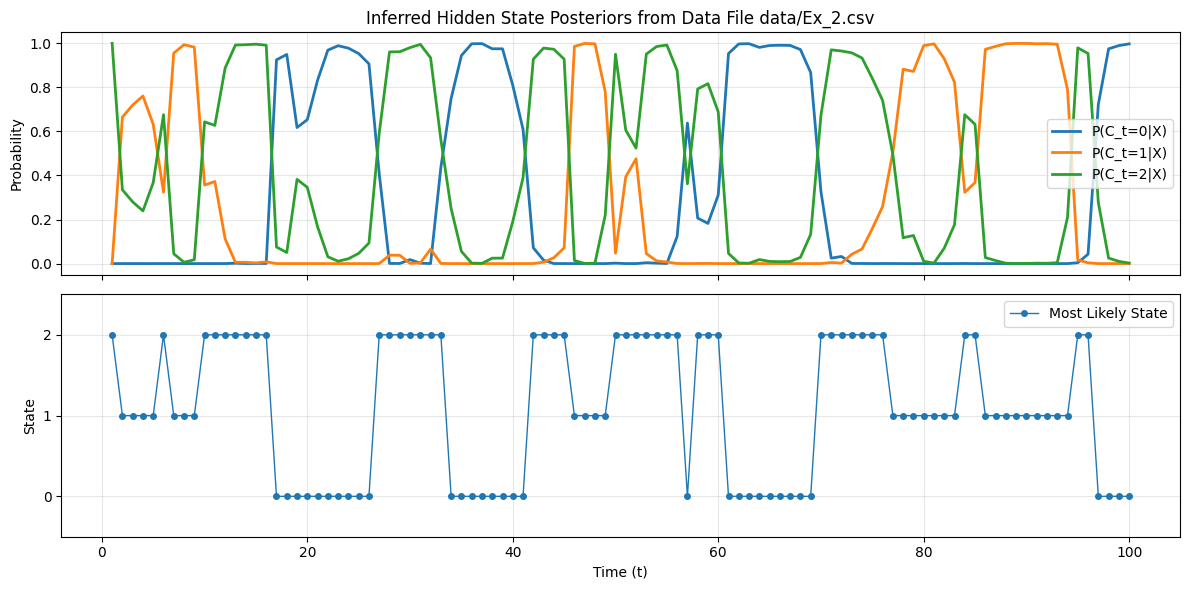

INFERENCE RESULTS ON DATA FILE
Data shape: T=100, n=8

State transition proportions:
  State 0: 0.320
  State 1: 0.270
  State 2: 0.410

Mean posterior probabilities:
  P(C_t=0|X): 0.3112
  P(C_t=1|X): 0.2788
  P(C_t=2|X): 0.4099


In [8]:
# Load data from file and run inference
file_path = "data/Ex_2.csv"
df_data, t_data, X_data, T_data, n_data = load_data(file_path)

# Run inference on the loaded data
post_c_data, post_z_data = inference(X_data, T_data, n_data, beta, gamma, alpha, lambda0, lambda1)

# Visualize the inferred hidden state C_t
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot 1: Posterior probabilities for each state
for c in range(3):
    axes[0].plot(t_data, post_c_data[:, c], label=f"P(C_t={c}|X)", linewidth=2)
axes[0].set_ylabel("Probability")
axes[0].set_title(f"Inferred Hidden State Posteriors from Data File {file_path}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Most likely state at each time
most_likely_state = np.argmax(post_c_data, axis=1)
axes[1].plot(t_data, most_likely_state, marker="o", markersize=4, linewidth=1, label="Most Likely State")
axes[1].set_ylabel("State")
axes[1].set_xlabel("Time (t)")
axes[1].set_ylim(-0.5, 2.5)
axes[1].set_yticks([0, 1, 2])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 60)
print("INFERENCE RESULTS ON DATA FILE")
print("=" * 60)
print(f"Data shape: T={T_data}, n={n_data}")
print(f"\nState transition proportions:")
for c in range(3):
    print(f"  State {c}: {np.mean(most_likely_state == c):.3f}")
print(f"\nMean posterior probabilities:")
for c in range(3):
    print(f"  P(C_t={c}|X): {np.mean(post_c_data[:, c]):.4f}")

Faster inference algorithm


In [9]:
print(post_c_data[T_data-1])

[9.97580346e-01 4.14847975e-09 2.41965033e-03]


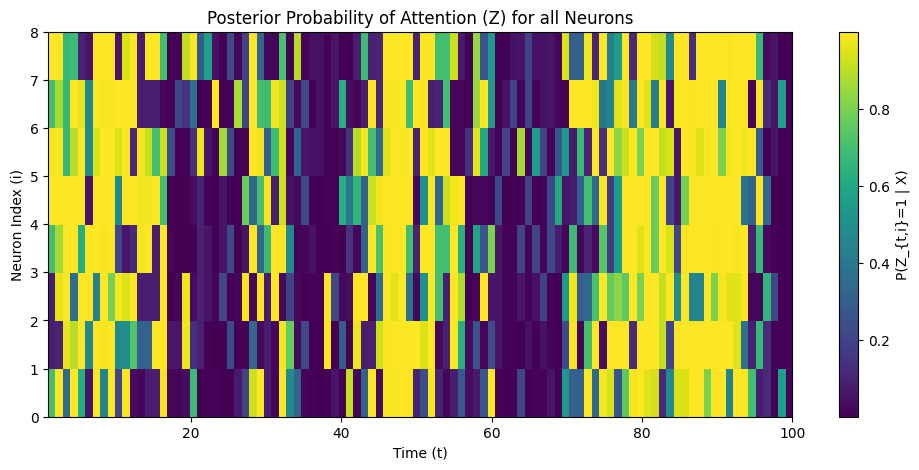

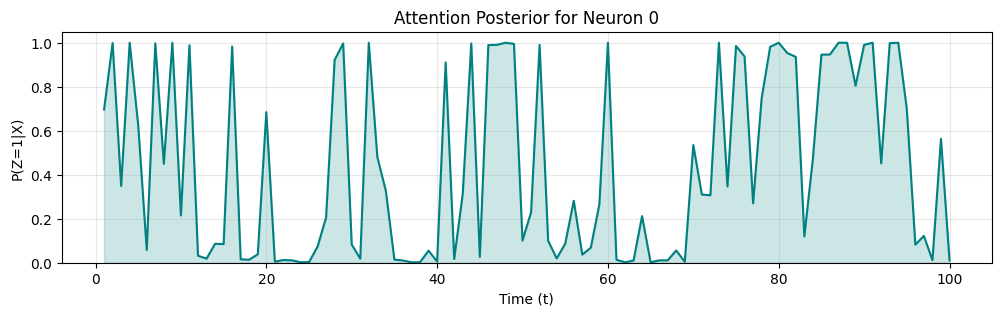

In [10]:
# Visualize the inferred attention Z_t,i
plt.figure(figsize=(12, 5))
# We transpose to have Neurons on y-axis and Time on x-axis
plt.imshow(post_z_data.T, aspect='auto', origin='lower',
           extent=[t_data[0], t_data[-1], 0, n_data])
plt.colorbar(label="P(Z_{t,i}=1 | X)")
plt.xlabel("Time (t)")
plt.ylabel("Neuron Index (i)")
plt.title("Posterior Probability of Attention (Z) for all Neurons")
plt.show()

# Optional: Plot a single neuron's attention over time for clarity
plt.figure(figsize=(12, 3))
neuron_idx = 0 # Change this to see different neurons
plt.plot(t_data, post_z_data[:, neuron_idx], color='teal')
plt.fill_between(t_data, post_z_data[:, neuron_idx], alpha=0.2, color='teal')
plt.title(f"Attention Posterior for Neuron {neuron_idx}")
plt.ylabel("P(Z=1|X)")
plt.xlabel("Time (t)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

## Learning Parameters


In [11]:
def learn_all_observed(X_list, Z_list, C_list):

    # Accumulators for means and alpha
    sum_x0, count_x0 = 0, 0
    sum_x1, count_x1 = 0, 0
    alpha_matches, alpha_total = 0, 0

    # Accumulators for transitions
    beta_num, beta_den = 0, 0
    gamma_num, gamma_den = 0, 0

    for X, Z, C in zip(X_list, Z_list, C_list):
        n_i = X.shape[1]

        # 1. Lambda: just counts and sums
        sum_x0 += np.sum(X[Z == 0])
        count_x0 += np.sum(Z == 0)
        sum_x1 += np.sum(X[Z == 1])
        count_x1 += np.sum(Z == 1)

        # 2. Alpha: Relative frequency in serial states
        serial_mask = (C[:, np.newaxis] == 0) | (C[:, np.newaxis] == 1)
        matches = ((Z == 0) & (C[:, np.newaxis] == 0)) | \
                  ((Z == 1) & (C[:, np.newaxis] == 1))
        alpha_matches += np.sum(matches)
        alpha_total += np.sum(serial_mask) * n_i

        # 3. Transitions: only look within the sequence of a dataset, not across datasets
        c_curr = C[:-1]
        c_next = C[1:]

        # Beta
        beta_num += np.sum((c_curr == 2) & (c_next != 2))
        beta_den += np.sum(c_curr == 2)

        # Gamma
        gamma_num += np.sum((c_curr != 2) & (c_next == 2))
        gamma_den += np.sum(c_curr != 2)

    # Final MLE calculations
    l0 = sum_x0 / count_x0 if count_x0 > 0 else 0
    l1 = sum_x1 / count_x1 if count_x1 > 0 else 0
    a = alpha_matches / alpha_total if alpha_total > 0 else 0.5
    b = beta_num / beta_den if beta_den > 0 else 0
    g = gamma_num / gamma_den if gamma_den > 0 else 0

    return l0, l1, a, b, g


#simulate data and learn parameters

def sim_data(T, n, N, beta, gamma, alpha, lambda0, lambda1):
    allC = []
    allZ = []
    allX = []
    for _ in range(N):
        C_sim, Z_sim, X_sim = simulate_one_sequence(T, n, beta, gamma, alpha, lambda0, lambda1)
        allC.append(C_sim)
        allZ.append(Z_sim)
        allX.append(X_sim)
    return allX, allZ, allC

parameters = {
    "beta": 0.2,
    "gamma": 0.1,
    "alpha": 0.9,
    "lambda0": 1,
    "lambda1": 5
}
allX, allZ, allC = sim_data(50, 5, 1000, **parameters)

lambda0, lambda1, alpha, beta, gamma = learn_all_observed(allX, allZ, allC)
print(f"Learned parameters:")
print(f"  lambda0: {lambda0:.4f}, diff: {lambda0 - parameters['lambda0']:.4f}")
print(f"  lambda1: {lambda1:.4f}, diff: {lambda1 - parameters['lambda1']:.4f}")
print(f"  alpha:   {alpha:.4f}, diff: {alpha - parameters['alpha']:.4f}")
print(f"  beta:    {beta:.4f}, diff: {beta - parameters['beta']:.4f}")
print(f"  gamma:   {gamma:.4f}, diff: {gamma - parameters['gamma']:.4f}")


Learned parameters:
  lambda0: 0.9984, diff: -0.0016
  lambda1: 5.0021, diff: 0.0021
  alpha:   0.8991, diff: -0.0009
  beta:    0.1970, diff: -0.0030
  gamma:   0.1020, diff: 0.0020


In [12]:
#Hard EM

def learn_only_x(X, initial_params, max_iter=50, tolerance=1e-4):
    params = initial_params.copy()

    for i in range(max_iter):
        print(f"EM Iteration {i+1}")
        X_list = X
        C_hard_list = []
        Z_hard_list = []

        for X_seq in X_list:
            post_c, post_z = inference(
                X_seq,
                T=X_seq.shape[0],
                n=X_seq.shape[1],
                beta=params['beta'],
                gamma=params['gamma'],
                alpha=params['alpha'],
                lam0=params['lambda0'],
                lam1=params['lambda1'],
            )
            C_hard_list.append(np.argmax(post_c, axis=1))
            Z_hard_list.append((post_z > 0.5).astype(int))

        new_lambda0, new_lambda1, new_alpha, new_beta, new_gamma = learn_all_observed(
            X_list, Z_hard_list, C_hard_list
        )

        param_diff = (
            np.abs(params['lambda0'] - new_lambda0)
            + np.abs(params['lambda1'] - new_lambda1)
            + np.abs(params['alpha'] - new_alpha)
            + np.abs(params['beta'] - new_beta)
            + np.abs(params['gamma'] - new_gamma)
        )

        if param_diff < tolerance:
            break

        params.update({
            'lambda0': new_lambda0,
            'lambda1': new_lambda1,
            'alpha': new_alpha,
            'beta': new_beta,
            'gamma': new_gamma,
        })

    return params

actual_params = {'lambda0': 1, 'lambda1': 5, 'alpha': 0.9, 'beta': 0.2, 'gamma': 0.1}
X, _, _ = sim_data(T=200, n=10, N=1000, **actual_params)

initial_params = {'lambda0': 0.5, 'lambda1': 4.0, 'alpha': 0.8, 'beta': 0.4, 'gamma': 0.05}

estimated_params = learn_only_x(X, initial_params)
print(f"Estimated parameters after EM:")
for param, value in estimated_params.items():
    print(f"  {param}: {value:.4f}, diff: {value - actual_params[param]:.4f}")


EM Iteration 1


KeyboardInterrupt: 

In [ ]:
Xlist = []
for i in range(10):
    filepath = f"data/Ex_{i+1}.csv"
    _, _, X, _, _ = load_data(filepath)
    Xlist.append(X)

initial_params = {'lambda0': 1, 'lambda1': 5, 'alpha': 0.9, 'beta': 0.2, 'gamma': 0.1}

estimated_params = learn_only_x(Xlist, initial_params)
print("Estimated parameters across all files:")
for param, value in estimated_params.items():
    print(f"  {param}: {value:.4f}")

EM Iteration 1
EM Iteration 2
EM Iteration 3
EM Iteration 4
EM Iteration 5
EM Iteration 6
EM Iteration 7
Estimated parameters across all files:
  lambda0: 0.8343
  lambda1: 4.9482
  alpha: 0.8785
  beta: 0.1294
  gamma: 0.0765


In [ ]:
#soft EM
def learn_all_observed_soft(X_list, post_z_list, post_c_list):
    # Accumulators for Weighted Sums (Numerators) and Total Weights (Denominators)
    sum_x_z0, weight_z0 = 0, 0
    sum_x_z1, weight_z1 = 0, 0
    alpha_num, alpha_den = 0, 0
    beta_num, beta_den = 0, 0
    gamma_num, gamma_den = 0, 0

    for X, post_z, post_c in zip(X_list, post_z_list, post_c_list):
        T, n = X.shape
        
        # 1. Lambda: Weighted average of spikes
        # post_z is the probability P(Z=1). So (1 - post_z) is P(Z=0)
        sum_x_z1 += np.sum(X * post_z)
        weight_z1 += np.sum(post_z)
        
        sum_x_z0 += np.sum(X * (1 - post_z))
        weight_z0 += np.sum(1 - post_z)

        # 2. Alpha: Weighted frequency of Z matching C in serial states
        # Expected matches: (P(Z=0) * P(C=0)) + (P(Z=1) * P(C=1))
        pC0 = post_c[:, 0][:, np.newaxis] # Shape (T, 1)
        pC1 = post_c[:, 1][:, np.newaxis] # Shape (T, 1)
        
        alpha_num += np.sum((1 - post_z) * pC0 + post_z * pC1)
        alpha_den += np.sum(pC0 + pC1) * n

        # 3. Transitions: Expected transitions using joint probabilities
        # Note: True Soft EM for transitions requires xi_t(c, c'), 
        # but a common "Soft-ish" approximation uses the product of marginals:
        pc_curr = post_c[:-1]
        pc_next = post_c[1:]
        
        # Expected time in State 2 (Parallel)
        prob_c2 = pc_curr[:, 2]
        # Expected transitions 2 -> {0, 1}
        prob_2_to_serial = prob_c2 * (pc_next[:, 0] + pc_next[:, 1])
        
        beta_num += np.sum(prob_2_to_serial)
        beta_den += np.sum(prob_c2)
        
        # Expected time in State 0 or 1 (Serial)
        prob_serial = pc_curr[:, 0] + pc_curr[:, 1]
        # Expected transitions {0, 1} -> 2
        prob_serial_to_2 = prob_serial * pc_next[:, 2]
        
        gamma_num += np.sum(prob_serial_to_2)
        gamma_den += np.sum(prob_serial)

    return (sum_x_z0 / weight_z0, sum_x_z1 / weight_z1, 
            alpha_num / alpha_den, beta_num / beta_den, gamma_num / gamma_den)


def learn_only_x_soft(X, initial_params, max_iter=50, tolerance=1e-4):
    params = initial_params.copy()

    for i in range(max_iter):
        print(f"Soft EM Iteration {i+1}")

        X_list = X
        C_post_list = []
        Z_post_list = []

        for X_seq in X_list:
            post_c, post_z = inference(
                X_seq,
                T=X_seq.shape[0],
                n=X_seq.shape[1],
                beta=params['beta'],
                gamma=params['gamma'],
                alpha=params['alpha'],
                lam0=params['lambda0'],
                lam1=params['lambda1'],
            )
            C_post_list.append(post_c)
            Z_post_list.append(post_z)

        new_lambda0, new_lambda1, new_alpha, new_beta, new_gamma = learn_all_observed_soft(
            X_list, Z_post_list, C_post_list
        )

        param_diff = (
            np.abs(params['lambda0'] - new_lambda0)
            + np.abs(params['lambda1'] - new_lambda1)
            + np.abs(params['alpha'] - new_alpha)
            + np.abs(params['beta'] - new_beta)
            + np.abs(params['gamma'] - new_gamma)
        )

        if param_diff < tolerance:
            break

        params.update({
            'lambda0': new_lambda0,
            'lambda1': new_lambda1,
            'alpha': new_alpha,
            'beta': new_beta,
            'gamma': new_gamma,
        })

    return params

actual_params = {'lambda0': 1, 'lambda1': 5, 'alpha': 0.9, 'beta': 0.2, 'gamma': 0.1}
X, _, _ = sim_data(T=200, n=10, N=1000, **actual_params)

initial_params = {'lambda0': 0.5, 'lambda1': 4.0, 'alpha': 0.8, 'beta': 0.4, 'gamma': 0.05}

estimated_params = learn_only_x_soft(X, initial_params)
print(f"Estimated parameters after EM:")
for param, value in estimated_params.items():
    print(f"  {param}: {value:.4f}, diff: {value - actual_params[param]:.4f}")

Soft EM Iteration 1
Soft EM Iteration 2
Soft EM Iteration 3
Soft EM Iteration 4
Soft EM Iteration 5
Soft EM Iteration 6
Soft EM Iteration 7
Soft EM Iteration 8
Soft EM Iteration 9
Soft EM Iteration 10
Soft EM Iteration 11
Soft EM Iteration 12
Soft EM Iteration 13
Soft EM Iteration 14
Soft EM Iteration 15
Soft EM Iteration 16
Soft EM Iteration 17
Estimated parameters after EM:
  lambda0: 0.9943, diff: -0.0057
  lambda1: 5.0098, diff: 0.0098
  alpha: 0.8778, diff: -0.0222
  beta: 0.2596, diff: 0.0596
  gamma: 0.1235, diff: 0.0235


In [ ]:
Xlist = []
for i in range(10):
    filepath = f"data/Ex_{i+1}.csv"
    _, _, X, _, _ = load_data(filepath)
    Xlist.append(X)

initial_params = {'lambda0': 1, 'lambda1': 5, 'alpha': 0.9, 'beta': 0.2, 'gamma': 0.1}

estimated_params = learn_only_x_soft(Xlist, initial_params)
print("Estimated parameters across all files:")
for param, value in estimated_params.items():
    print(f"  {param}: {value:.4f}")

Soft EM Iteration 1
Soft EM Iteration 2
Soft EM Iteration 3
Soft EM Iteration 4
Soft EM Iteration 5
Soft EM Iteration 6
Soft EM Iteration 7
Soft EM Iteration 8
Soft EM Iteration 9
Soft EM Iteration 10
Soft EM Iteration 11
Soft EM Iteration 12
Soft EM Iteration 13
Soft EM Iteration 14
Soft EM Iteration 15
Soft EM Iteration 16
Soft EM Iteration 17
Soft EM Iteration 18
Soft EM Iteration 19
Soft EM Iteration 20
Soft EM Iteration 21
Soft EM Iteration 22
Soft EM Iteration 23
Soft EM Iteration 24
Soft EM Iteration 25
Soft EM Iteration 26
Soft EM Iteration 27
Soft EM Iteration 28
Soft EM Iteration 29
Soft EM Iteration 30
Soft EM Iteration 31
Soft EM Iteration 32
Soft EM Iteration 33
Soft EM Iteration 34
Soft EM Iteration 35
Soft EM Iteration 36
Soft EM Iteration 37
Soft EM Iteration 38
Soft EM Iteration 39
Soft EM Iteration 40
Estimated parameters across all files:
  lambda0: 0.8151
  lambda1: 4.5629
  alpha: 0.8046
  beta: 0.5216
  gamma: 0.1638
